In [1]:
import time
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


df_train = pd.read_csv("train.csv")
df_train = df_train.drop(columns=["id"])

feature_encoders = {}

cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.drop("class")

for col in cat_cols:
  le = LabelEncoder()
  df_train[col] = le.fit_transform(df_train[col].astype(str))
  feature_encoders[col] = le

target_encoder = LabelEncoder()
df_train["class"] = target_encoder.fit_transform(df_train["class"])

X = df_train.drop(columns=["class"])
y = df_train["class"]

class_labels = np.arange(len(target_encoder.classes_))
original_classes = target_encoder.inverse_transform(class_labels)

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# def objective(trial):
#   start_time = time.time()

#   params = {
#     "loss": trial.suggest_categorical(
#       "loss",
#       ["hinge", "log_loss", "modified_huber", "squared_hinge"]
#     ),
#     "penalty": trial.suggest_categorical(
#       "penalty",
#       ["l2", "l1", "elasticnet"]
#     ),
#     "alpha": trial.suggest_float("alpha", 1e-6, 1e-1, log=True),
#     "learning_rate": trial.suggest_categorical(
#       "learning_rate",
#       ["optimal", "invscaling", "adaptive"]
#     ),
#     "eta0": trial.suggest_float("eta0", 1e-4, 1e-1, log=True),
#     "max_iter": trial.suggest_int("max_iter", 500, 3000),
#     "tol": trial.suggest_float("tol", 1e-5, 1e-2, log=True),
#     "random_state": 42
#   }

#   if params["penalty"] == "elasticnet":
#     params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.05, 0.95)

#   model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("classifier", SGDClassifier(**params))
#   ])

#   fold_scores = []
#   overall_cm = np.zeros((len(class_labels), len(class_labels)), dtype=int)

#   for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)

#     acc = accuracy_score(y_test, y_pred)
#     fold_scores.append(acc)

#     cm = confusion_matrix(y_test, y_pred, labels=class_labels)
#     overall_cm += cm

#   mean_acc = np.mean(fold_scores)
#   std_acc = np.std(fold_scores)
#   fit_time = time.time() - start_time

#   trial.set_user_attr("mean_accuracy", mean_acc)
#   trial.set_user_attr("std_accuracy", std_acc)
#   trial.set_user_attr("fit_time_sec", fit_time)
#   trial.set_user_attr("accuracy_per_second", mean_acc / fit_time)
#   trial.set_user_attr("confusion_matrix", overall_cm.tolist())

#   for i, acc in enumerate(fold_scores, start=1):
#     trial.set_user_attr(f"fold_{i}_accuracy", acc)

#   return mean_acc


# study = optuna.create_study(direction="maximize")

# study.optimize(
#   objective,
#   n_trials=36,
#   n_jobs=-1
# )

# print("Best accuracy:", study.best_value)
# print("Best params:", study.best_params)

# results_df = study.trials_dataframe()
# results_df = results_df.sort_values(by="value", ascending=False)

# results_df.to_csv("optuna_sgdclassifier_results.csv", index=False)

# print(results_df.head())



# run for 115 minutes

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import joblib

# joblib.dump(study, "study_sgdclassifier.pkl")

In [3]:
# import ast
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.read_csv("optuna_sgdclassifier_results.csv")

# top4 = df.sort_values("value", ascending=False).head(4)

# param_cols = [c for c in df.columns if c.startswith("params_")]

# fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# axes = axes.flatten()

# for ax, (_, row) in zip(axes, top4.iterrows()):

#   cm = np.array(ast.literal_eval(row["user_attrs_confusion_matrix"]))

#   cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

#   params = []

#   for c in param_cols:
#     if pd.notna(row[c]):
#       value = row[c]

#       if isinstance(value, float):
#         value = f"{value:.3f}"

#       params.append(f"{c.replace('params_', '')}={value}")

#   params_text = ", ".join(params)

#   title = (
#     f"Trial {int(row['number'])}\n"
#     f"Mean Acc = {row['user_attrs_mean_accuracy']:.4f}\n"
#     f"Std Acc = {row['user_attrs_std_accuracy']:.4f}"
#   )

#   sns.heatmap(
#     cm_percent,
#     annot=True,
#     fmt=".1f",
#     cmap="Blues",
#     vmin=0,
#     vmax=100,
#     xticklabels=original_classes,
#     yticklabels=original_classes,
#     cbar=True,
#     ax=ax
#   )

#   ax.set_title(title, fontsize=11)
#   ax.set_xlabel("Predicted")
#   ax.set_ylabel("True")
#   ax.text(
#     0.5,
#     -0.35,
#     "\n".join(params),
#     transform=ax.transAxes,
#     ha="center",
#     va="top",
#     fontsize=8
#   )

# plt.tight_layout()
# plt.savefig("top4_models_confusion_matrix_percentage.png", dpi=300)
# plt.show()

# Top 4 models by acc

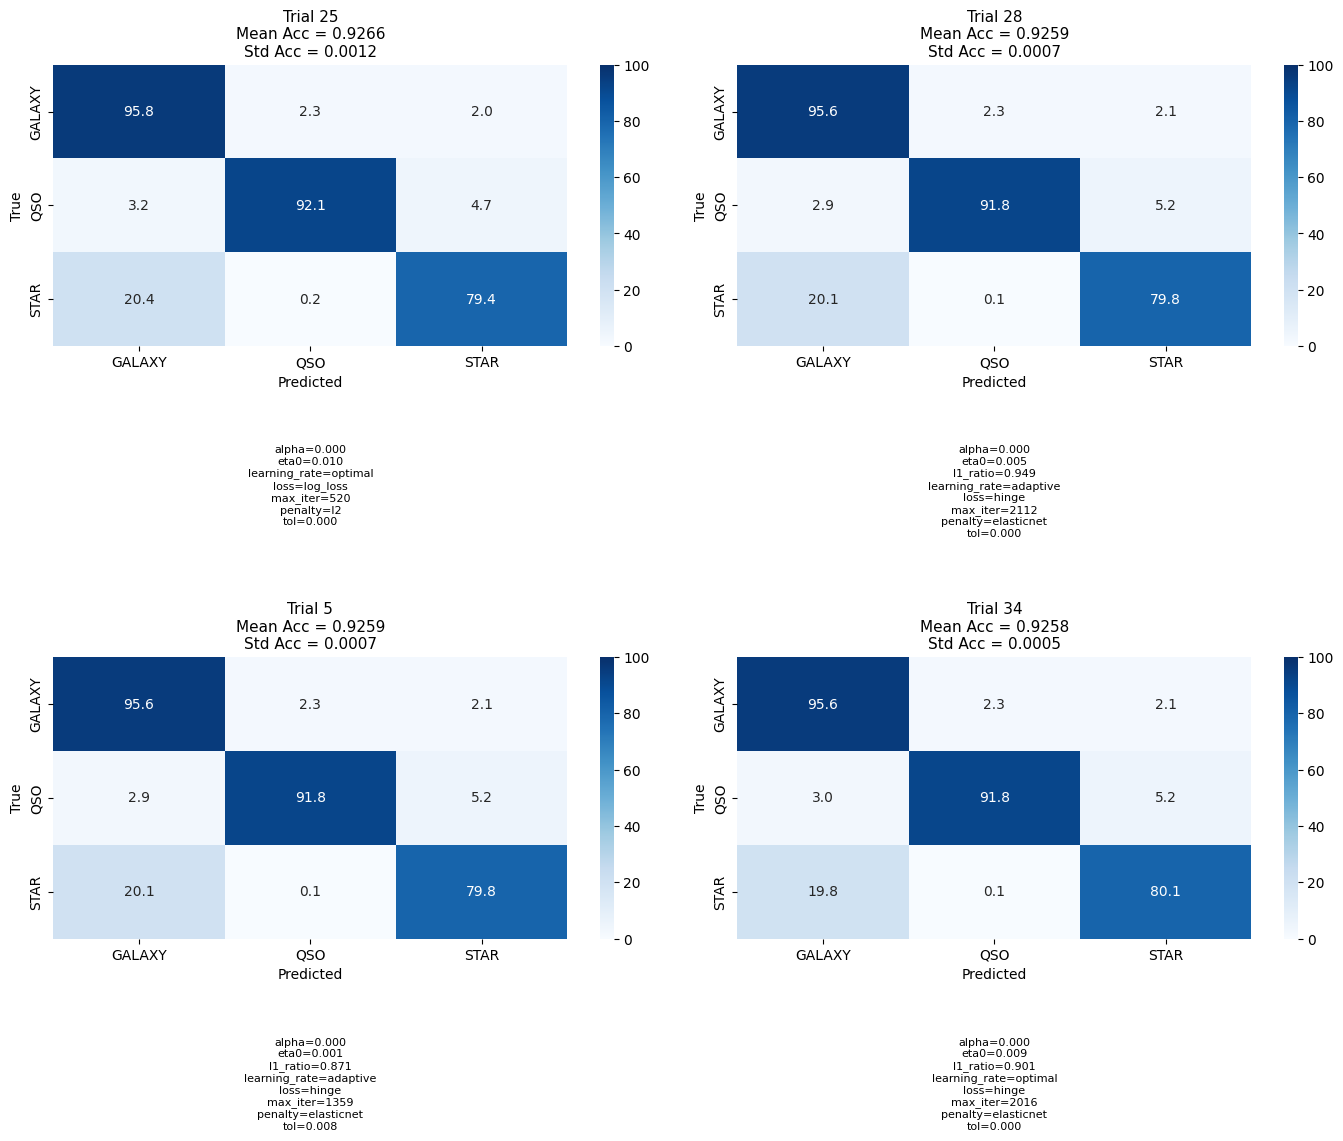

In [4]:
# import ast
# import math
# import textwrap
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = pd.read_csv("optuna_sgdclassifier_results.csv")

# df = df.dropna(subset=["user_attrs_confusion_matrix"])

# # Sort models by accuracy, best first
# df = df.sort_values(by="user_attrs_mean_accuracy", ascending=False)

# n_cols = 4
# n_rows = math.ceil(len(df) / n_cols)

# fig, axes = plt.subplots(
#   n_rows,
#   n_cols,
#   figsize=(7 * n_cols, 6 * n_rows)
# )

# axes = np.array(axes).reshape(-1)

# param_cols = [c for c in df.columns if c.startswith("params_")]

# for rank, (ax, (_, row)) in enumerate(zip(axes, df.iterrows()), start=1):
#   cm = np.array(ast.literal_eval(row["user_attrs_confusion_matrix"]))
#   cm = cm / cm.sum(axis=1, keepdims=True) * 100

#   mean_acc = row["user_attrs_mean_accuracy"]
#   std_acc = row["user_attrs_std_accuracy"]

#   params = []

#   for c in param_cols:
#     if pd.isna(row[c]):
#       continue

#     value = row[c]

#     if isinstance(value, float):
#       value = f"{value:.3f}"

#     params.append(f"{c.replace('params_', '')}={value}")

#   params_text = ", ".join(params)

#   title = (
#     f"Rank {rank} | Trial {int(row['number'])}\n"
#     f"Mean acc = {mean_acc:.3f}, Std acc = {std_acc:.3f}\n"
#     f"{params_text}"
#   )

#   title = "\n".join(textwrap.wrap(title, width=85))

#   sns.heatmap(
#     cm,
#     annot=True,
#     fmt=".1f",
#     cmap="Blues",
#     xticklabels=original_classes,
#     yticklabels=original_classes,
#     ax=ax
#   )

#   ax.set_title(title, fontsize=9)
#   ax.set_xlabel("Predicted")
#   ax.set_ylabel("True")

# for ax in axes[len(df):]:
#   fig.delaxes(ax)

# plt.tight_layout()

# plt.savefig(
#   "all_36_models_confusion_matrices_sorted_by_accuracy.png",
#   dpi=300,
#   bbox_inches="tight"
# )

# plt.show()

# All 36 models

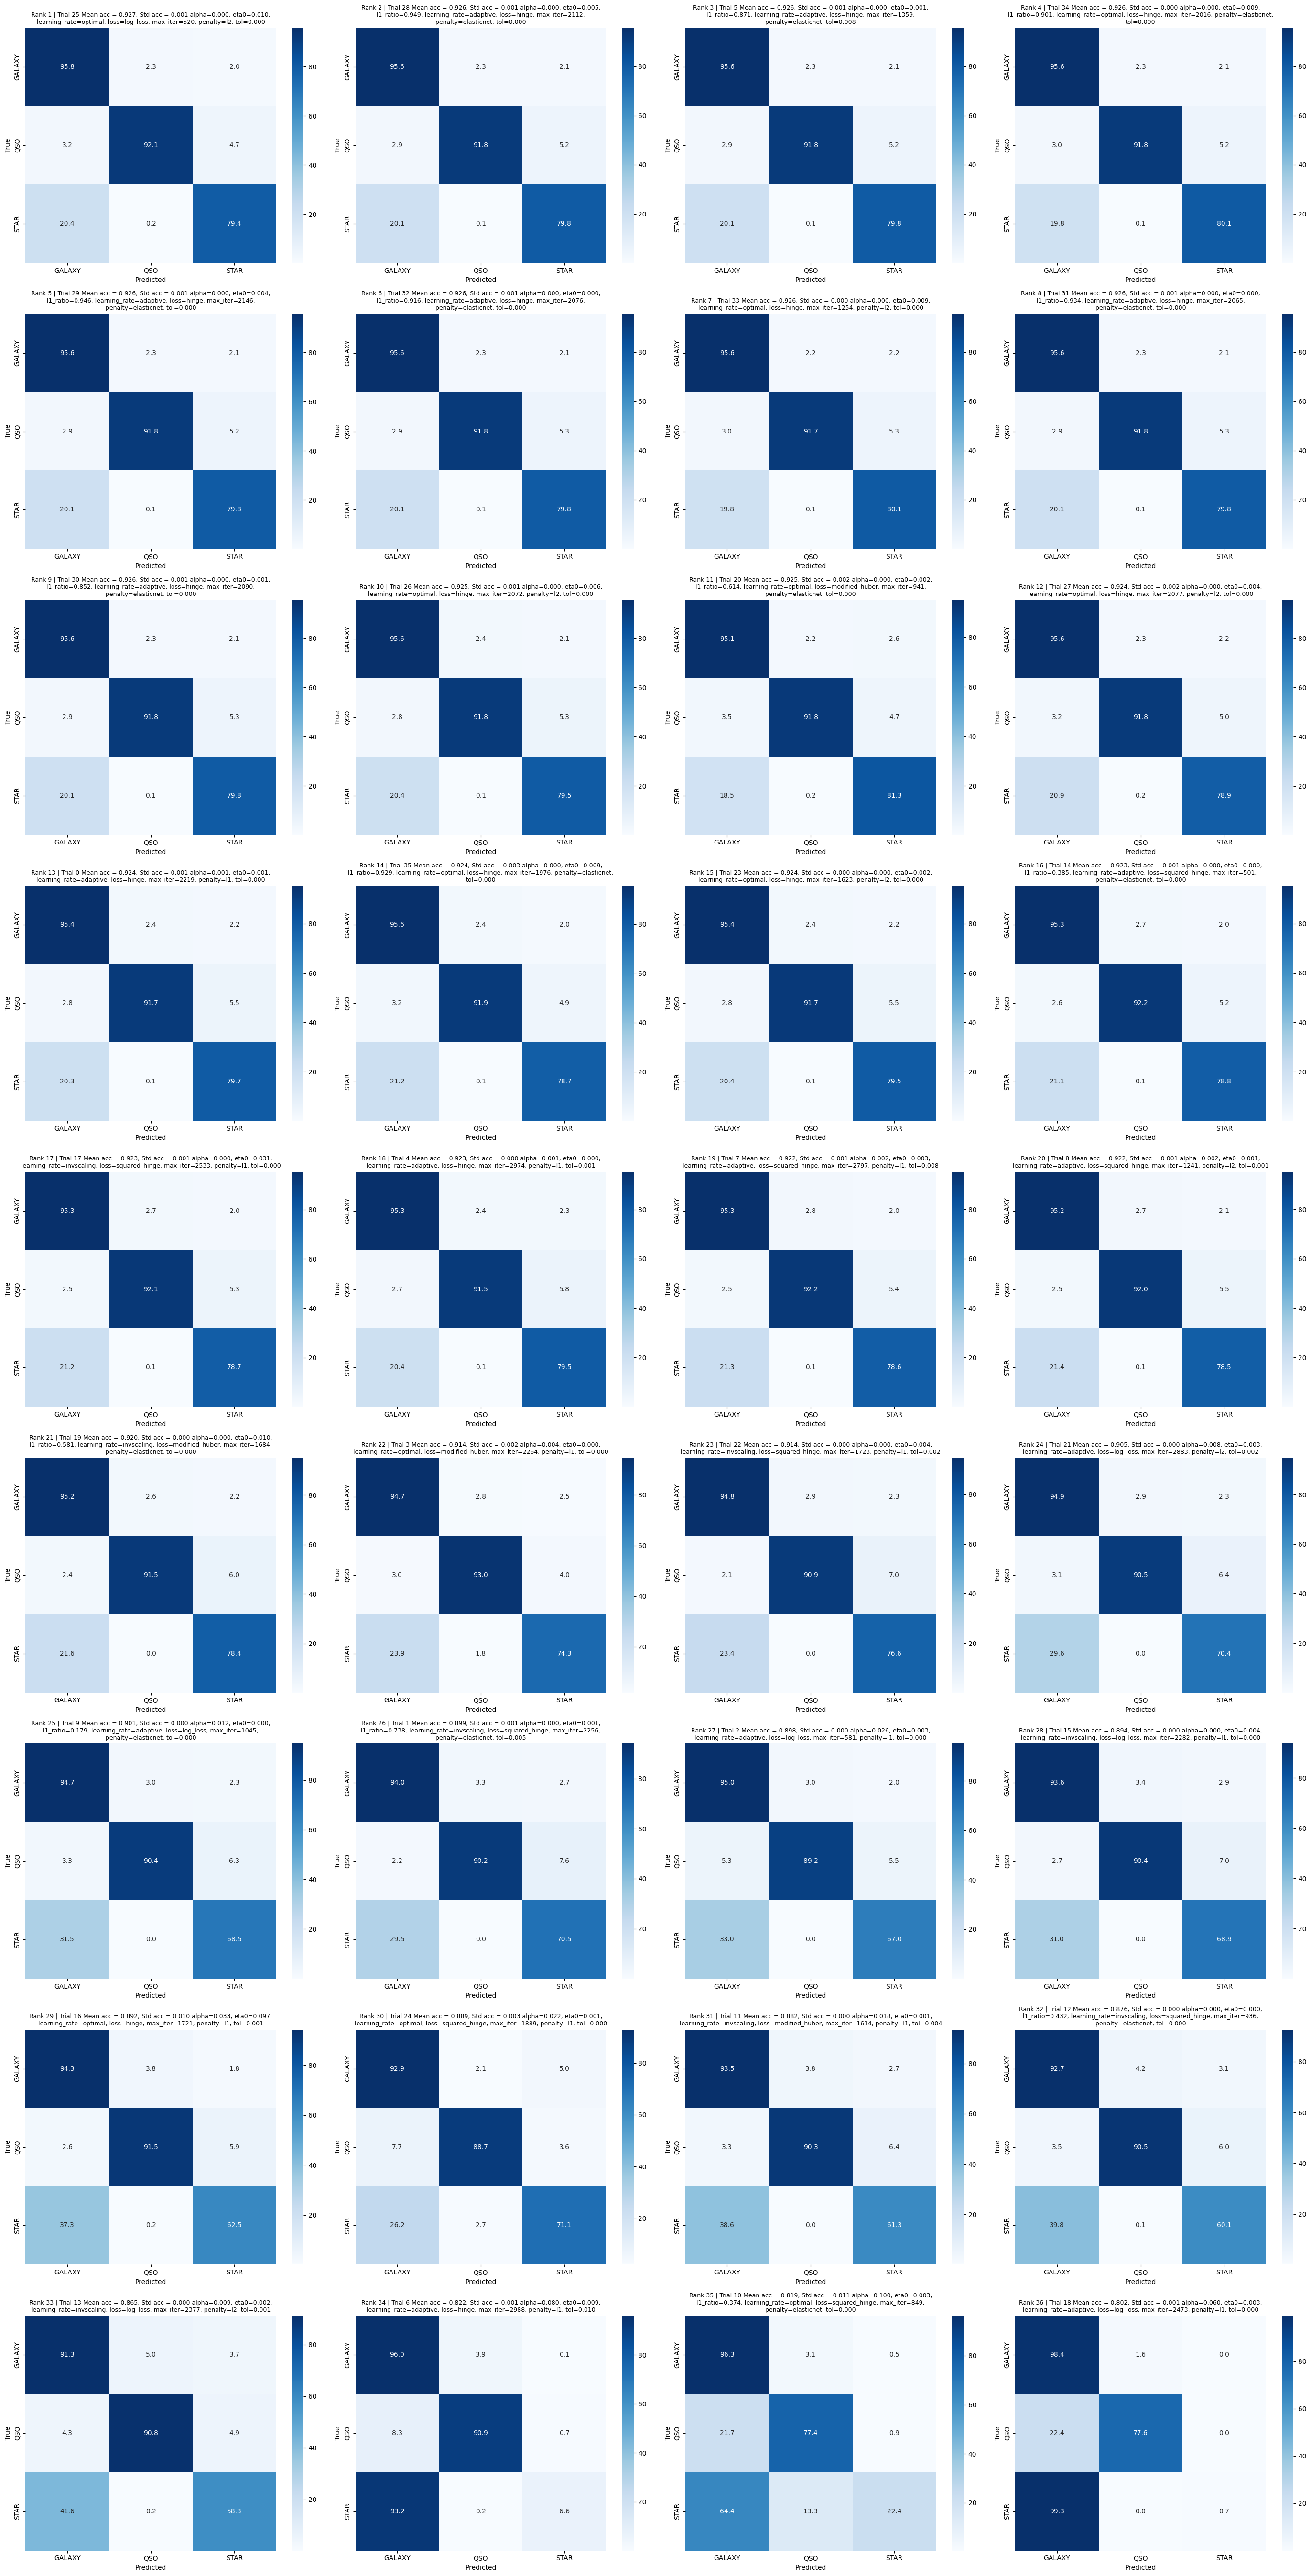

# Trial 25
LB: 0.87469

In [5]:
# import pandas as pd
# import numpy as np

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.linear_model import SGDClassifier


# df_train = pd.read_csv("train.csv")
# df_test = pd.read_csv("test.csv")

# test_ids = df_test["id"]

# df_train = df_train.drop(columns=["id"])
# df_test = df_test.drop(columns=["id"])


# feature_encoders = {}

# cat_cols = df_train.select_dtypes(
#   include=["object", "category"]
# ).columns.drop("class")

# for col in cat_cols:
#   le = LabelEncoder()

#   df_train[col] = le.fit_transform(df_train[col].astype(str))
#   feature_encoders[col] = le

#   test_values = df_test[col].astype(str)

#   known_classes = set(le.classes_)
#   test_values = test_values.apply(
#     lambda x: x if x in known_classes else le.classes_[0]
#   )

#   df_test[col] = le.transform(test_values)


# target_encoder = LabelEncoder()
# df_train["class"] = target_encoder.fit_transform(df_train["class"])


# X = df_train.drop(columns=["class"])
# y = df_train["class"]

# X_test = df_test[X.columns]

# results_df = pd.read_csv("optuna_sgdclassifier_results.csv")

# trial = results_df[results_df["number"] == 25].iloc[0]

# params = {
#   "loss": trial["params_loss"],
#   "penalty": trial["params_penalty"],
#   "alpha": float(trial["params_alpha"]),
#   "learning_rate": trial["params_learning_rate"],
#   "eta0": float(trial["params_eta0"]),
#   "max_iter": int(trial["params_max_iter"]),
#   "tol": float(trial["params_tol"]),
#   "random_state": 42
# }

# if params["penalty"] == "elasticnet":
#   params["l1_ratio"] = float(trial["params_l1_ratio"])


# model = Pipeline([
#   ("scaler", StandardScaler()),
#   ("classifier", SGDClassifier(**params))
# ])

# model.fit(X, y)


# y_pred_encoded = model.predict(X_test)
# y_pred = target_encoder.inverse_transform(y_pred_encoded)


# output = pd.DataFrame({
#   "id": test_ids,
#   "class": y_pred
# })

# output.to_csv("output.csv", index=False)

# Ensemble best 5 models
LB: 0.88894

In [ ]:
# import pandas as pd
# import numpy as np

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.linear_model import SGDClassifier
# from scipy.stats import mode

# df_train = pd.read_csv("train.csv")
# df_test = pd.read_csv("test.csv")

# test_ids = df_test["id"]

# df_train = df_train.drop(columns=["id"])
# df_test = df_test.drop(columns=["id"])

# feature_encoders = {}

# cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.drop("class")

# for col in cat_cols:
#   le = LabelEncoder()
#   df_train[col] = le.fit_transform(df_train[col].astype(str))
#   feature_encoders[col] = le

#   test = df_test[col].astype(str)
#   test = test.apply(lambda x: x if x in le.classes_ else le.classes_[0])
#   df_test[col] = le.transform(test)

# target_encoder = LabelEncoder()
# df_train["class"] = target_encoder.fit_transform(df_train["class"])

# X = df_train.drop(columns=["class"])
# y = df_train["class"]

# X_test = df_test[X.columns]


# results = pd.read_csv("optuna_sgdclassifier_results.csv")

# top5 = results.sort_values(
#   "user_attrs_mean_accuracy",
#   ascending=False
# ).head(5)

# predictions = []

# for _, trial in top5.iterrows():

#   params = {
#     "loss": trial["params_loss"],
#     "penalty": trial["params_penalty"],
#     "alpha": float(trial["params_alpha"]),
#     "learning_rate": trial["params_learning_rate"],
#     "eta0": float(trial["params_eta0"]),
#     "max_iter": int(trial["params_max_iter"]),
#     "tol": float(trial["params_tol"]),
#     "random_state": 42
#   }

#   if params["penalty"] == "elasticnet":
#     params["l1_ratio"] = float(trial["params_l1_ratio"])

#   model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("classifier", SGDClassifier(**params))
#   ])

#   model.fit(X, y)

#   pred = model.predict(X_test)

#   predictions.append(pred)

# predictions = np.array(predictions)

# ensemble_pred = mode(predictions, axis=0, keepdims=False).mode

# ensemble_pred = target_encoder.inverse_transform(ensemble_pred)

# output = pd.DataFrame({
#   "id": test_ids,
#   "class": ensemble_pred
# })

# output.to_csv("output_ensemble_top5.csv", index=False)

# print(output.head())

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
